In [6]:
import numpy as np

In [8]:
def f(x: int) -> int:
    return x**3 - 3.125*x**2 - 3.5*x + 2.458

def df(x: int) -> int:
    return 3*x**2 - 6.25*x - 3.5

In [14]:
a, b = -2, -1
print(f(a)*f(b))

df(a), df(b)
f(-1)

-20.239986000000002


1.8330000000000002

In [10]:
eps = 0.01

print("="*80)
print("ТАБЛИЦА 1. Уточнение корня уравнения методом половинного деления")
print("Интервал: [-2; -1] (Крайний левый корень)")
print("-" * 80)
print(f"{'№ шага':<8} | {'a':<8} | {'b':<8} | {'x':<8} | {'f(a)':<8} | {'f(b)':<8} | {'f(x)':<8} | {'|a-b|':<8}")
print("-" * 80)

a, b = -2.0, -1.0
step = 1
while True:
    x = (a + b) / 2
    fa, fb, fx = f(a), f(b), f(x)
    diff = abs(a - b)
    
    print(f"{step:<8} | {a:<8.3f} | {b:<8.3f} | {x:<8.3f} | {fa:<8.3f} | {fb:<8.3f} | {fx:<8.3f} | {diff:<8.3f}")
    
    if diff <= eps:
        break
        
    if fa * fx < 0:
        b = x
    else:
        a = x
    step += 1


ТАБЛИЦА 1. Уточнение корня уравнения методом половинного деления
Интервал: [-2; -1] (Крайний левый корень)
--------------------------------------------------------------------------------
№ шага   | a        | b        | x        | f(a)     | f(b)     | f(x)     | |a-b|   
--------------------------------------------------------------------------------
1        | -2.000   | -1.000   | -1.500   | -11.042  | 1.833    | -2.698   | 1.000   
2        | -1.500   | -1.000   | -1.250   | -2.698   | 1.833    | -0.003   | 0.500   
3        | -1.250   | -1.000   | -1.125   | -0.003   | 1.833    | 1.017    | 0.250   
4        | -1.250   | -1.125   | -1.188   | -0.003   | 1.017    | 0.533    | 0.125   
5        | -1.250   | -1.188   | -1.219   | -0.003   | 0.533    | 0.272    | 0.062   
6        | -1.250   | -1.219   | -1.234   | -0.003   | 0.272    | 0.136    | 0.031   
7        | -1.250   | -1.234   | -1.242   | -0.003   | 0.136    | 0.067    | 0.016   
8        | -1.250   | -1.242   | -1.246   |

In [15]:
print("="*80)
print("\nТАБЛИЦА 3. Уточнение корня уравнения методом Ньютона")
print("Интервал: [3; 4] (Крайний правый корень)")
# Проверка: f(4) = 2.458 > 0; f''(4) = 17.75 > 0. Условие f(x0)*f''(x0) > 0 выполнено для x0 = 4.
print("-" * 65)
print(f"{'№ шага':<8} | {'xk':<8} | {'f(xk)':<8} | {'f''(xk)':<8} | {'xk+1':<8} | {'|xk+1-xk|':<8}")
print("-" * 65)

x0 = 4.0
step = 1
while True:
    fx = f(x0)
    dfx = df(x0)
    x1 = x0 - fx / dfx
    diff = abs(x1 - x0)
    
    print(f"{step:<8} | {x0:<8.3f} | {fx:<8.3f} | {dfx:<8.3f} | {x1:<8.3f} | {diff:<8.3f}")
    
    if diff <= eps:
        break
    x0 = x1
    step += 1


ТАБЛИЦА 3. Уточнение корня уравнения методом Ньютона
Интервал: [3; 4] (Крайний правый корень)
-----------------------------------------------------------------
№ шага   | xk       | f(xk)    | f(xk)    | xk+1     | |xk+1-xk|
-----------------------------------------------------------------
1        | 4.000    | 2.458    | 19.500   | 3.874    | 0.126   
2        | 3.874    | 0.139    | 17.310   | 3.866    | 0.008   


In [12]:
print("="*80)
print("\nТАБЛИЦА 5. Уточнение корня уравнения методом простой итерации")
print("Интервал: [0; 1] (Центральный корень)")

# Обоснование сходимости
print("\nПРОВЕРКА УСЛОВИЯ СХОДИМОСТИ:")
print("Уравнение: f(x) = x^3 - 3.125x^2 - 3.5x + 2.458 = 0")
print("Преобразуем к виду x = \u03c6(x) = x + \u03bb * f(x)")
print("На интервале [0; 1] производная f'(x) < 0. Максимальное по модулю значение f'(1) = -6.75.")
print("Выбираем \u03bb = 0.2 (так как 0 < \u03bb < 2 / 6.75 \u2248 0.29).")
print("Тогда \u03c6'(x) = 1 + 0.2 * (3x^2 - 6.25x - 3.5) = 0.3 + 0.6x^2 - 1.25x")
print("Проверяем граничные точки интервала:")
print("|\u03c6'(0)| = |0.3| = 0.3 < 1")
print("|\u03c6'(1)| = |-0.35| = 0.35 < 1")
print("Условие сходимости |\u03c6'(x)| \u2264 0.35 < 1 выполняется!")
print("-" * 60)

print(f"{'№ шага':<8} | {'xk':<8} | {'xk+1':<8} | {'f(xk+1)':<8} | {'|xk+1-xk|':<8}")
print("-" * 60)

x0 = 0.5 # Берем середину отрезка
step = 1
lmbd = 0.2 # Выбранная нами лямбда
while True:
    x1 = x0 + lmbd * f(x0)
    fx1 = f(x1)
    diff = abs(x1 - x0)
    
    print(f"{step:<8} | {x0:<8.3f} | {x1:<8.3f} | {fx1:<8.3f} | {diff:<8.3f}")
    
    if diff <= eps:
        break
    x0 = x1
    step += 1
print("="*80)


ТАБЛИЦА 5. Уточнение корня уравнения методом простой итерации
Интервал: [0; 1] (Центральный корень)

ПРОВЕРКА УСЛОВИЯ СХОДИМОСТИ:
Уравнение: f(x) = x^3 - 3.125x^2 - 3.5x + 2.458 = 0
Преобразуем к виду x = φ(x) = x + λ * f(x)
На интервале [0; 1] производная f'(x) < 0. Максимальное по модулю значение f'(1) = -6.75.
Выбираем λ = 0.2 (так как 0 < λ < 2 / 6.75 ≈ 0.29).
Тогда φ'(x) = 1 + 0.2 * (3x^2 - 6.25x - 3.5) = 0.3 + 0.6x^2 - 1.25x
Проверяем граничные точки интервала:
|φ'(0)| = |0.3| = 0.3 < 1
|φ'(1)| = |-0.35| = 0.35 < 1
Условие сходимости |φ'(x)| ≤ 0.35 < 1 выполняется!
------------------------------------------------------------
№ шага   | xk       | xk+1     | f(xk+1)  | |xk+1-xk|
------------------------------------------------------------
1        | 0.500    | 0.510    | -0.009   | 0.010   
2        | 0.510    | 0.509    | 0.002    | 0.002   


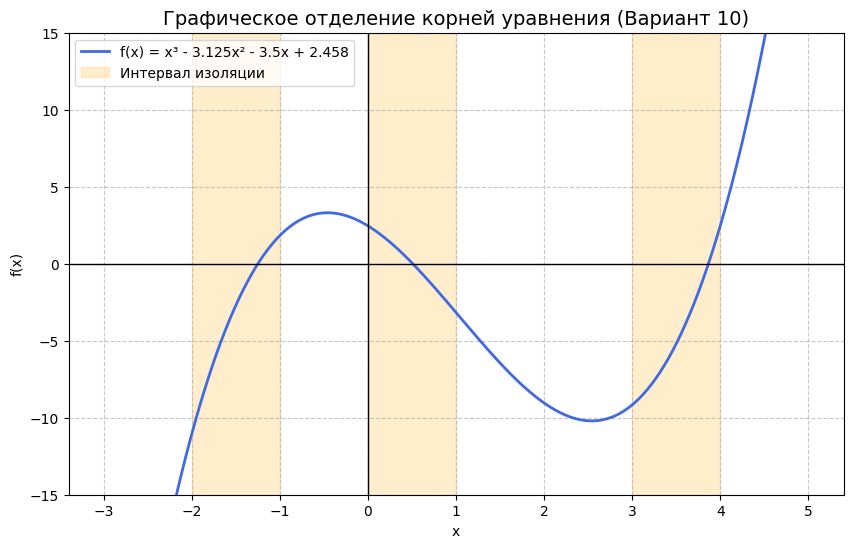

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Функция по варианту 10
def f(x):
    return x**3 - 3.125*x**2 - 3.5*x + 2.458

# Диапазон x для отображения всех корней
x = np.linspace(-3, 5, 500)
y = f(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y, label='f(x) = x³ - 3.125x² - 3.5x + 2.458', color='royalblue', linewidth=2)

# Оформление осей
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.7)

# Подсветка интервалов изоляции (из расчетов)
intervals = [(-2, -1), (0, 1), (3, 4)]
for i, (a, b) in enumerate(intervals):
    plt.axvspan(a, b, color='orange', alpha=0.2, label='Интервал изоляции' if i == 0 else "")

plt.title('Графическое отделение корней уравнения (Вариант 10)', fontsize=14)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.ylim(-15, 15)
plt.legend()
plt.show()

In [16]:
import math

# Начальные данные
# Берем точку из указанного вами квадрата 0 < x < 1, -1 < y < 0
x = 0.7  
y = -0.1
eps = 0.01

print(f"Определяем, что положительное решение системы уравнений находится в квадрате:\n0 < x < 1,  -1 < y < 0")
print(f"Выберем начальное приближение: x^(0) = {x}    y^(0) = {y}\n")

for k in range(1, 15):
    print(f"{k} шаг.")
    
    # Формируем строки с подставленными значениями (как на скрине)
    # Используем 3 знака после запятой для красоты вывода
    x_eq_str = f"-cos({y:.3f} - 2)"
    y_eq_str = f"sin({x:.3f} + 0.5) - 1"
    
    # Считаем новые значения
    x_new = -math.cos(y - 2)
    y_new = math.sin(x + 0.5) - 1
    
    # Считаем разницу для проверки критерия остановки
    dx = abs(x_new - x)
    dy = abs(y_new - y)
    
    # Определяем знак (больше или меньше эпсилон)
    sign_x = ">" if dx > eps else "<="
    sign_y = ">" if dy > eps else "<="
    
    # Выводим строку расчета переменной и строку проверки погрешности
    # \u03B5 — это символ эпсилон (ε)
    print(f"x^({k}) = {x_eq_str} = {x_new:.3f} \t\t |x^({k}) - x^({k-1})| = {dx:.3f} {sign_x} \u03B5")
    print(f"y^({k}) = {y_eq_str} = {y_new:.3f} \t\t |y^({k}) - y^({k-1})| = {dy:.3f} {sign_y} \u03B5")
    print("")
    
    # Проверка критерия окончания итерационного процесса
    if dx <= eps and dy <= eps:
        print("И т.д.")
        print(f"\nКритерий окончания выполнен на {k} шаге.")
        print(f"Ответ: x ≈ {x_new:.3f}, y ≈ {y_new:.3f}")
        break
        
    # Обновляем значения для следующего шага
    x = x_new
    y = y_new

Определяем, что положительное решение системы уравнений находится в квадрате:
0 < x < 1,  -1 < y < 0
Выберем начальное приближение: x^(0) = 0.7    y^(0) = -0.1

1 шаг.
x^(1) = -cos(-0.100 - 2) = 0.505 		 |x^(1) - x^(0)| = 0.195 > ε
y^(1) = sin(0.700 + 0.5) - 1 = -0.068 		 |y^(1) - y^(0)| = 0.032 > ε

2 шаг.
x^(2) = -cos(-0.068 - 2) = 0.477 		 |x^(2) - x^(1)| = 0.028 > ε
y^(2) = sin(0.505 + 0.5) - 1 = -0.156 		 |y^(2) - y^(1)| = 0.088 > ε

3 шаг.
x^(3) = -cos(-0.156 - 2) = 0.552 		 |x^(3) - x^(2)| = 0.075 > ε
y^(3) = sin(0.477 + 0.5) - 1 = -0.171 		 |y^(3) - y^(2)| = 0.015 > ε

4 шаг.
x^(4) = -cos(-0.171 - 2) = 0.565 		 |x^(4) - x^(3)| = 0.013 > ε
y^(4) = sin(0.552 + 0.5) - 1 = -0.131 		 |y^(4) - y^(3)| = 0.040 > ε

5 шаг.
x^(5) = -cos(-0.131 - 2) = 0.532 		 |x^(5) - x^(4)| = 0.033 > ε
y^(5) = sin(0.565 + 0.5) - 1 = -0.125 		 |y^(5) - y^(4)| = 0.006 <= ε

6 шаг.
x^(6) = -cos(-0.125 - 2) = 0.526 		 |x^(6) - x^(5)| = 0.005 <= ε
y^(6) = sin(0.532 + 0.5) - 1 = -0.142 		 |y^(6) - y^(5)| = 0.

In [3]:
int("f")

ValueError: invalid literal for int() with base 10: 'f'